## Section 0: Setup/Load files


In [120]:
#importing all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [121]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [122]:
BASE_PATH = '/content/drive/MyDrive/Instacart Kaggle/'

In [123]:
# reading all the files from cleaned folder inside instacart folder

customer_summary = pd.read_csv(BASE_PATH + 'cleaned/customer_summary.csv')
orders_clean = pd.read_csv(BASE_PATH + 'cleaned/orders_clean.csv')


In [124]:
# head function shows what are the contents in the csv

customer_summary.head()

,user_id,total_orders,avg_days_between,std_days_between,max_gap
0,1,11,19.000000,9.030811,30.0
1,2,15,16.285714,10.268912,30.0
2,3,12,12.090909,5.375026,21.0
3,4,5,13.750000,9.500000,21.0
4,5,5,11.500000,5.446712,19.0


In [125]:
# head function shows what are the contents in the csv

orders_clean.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [126]:
# shape function shows how many rows and columns exist in the csv
customer_summary.shape
orders_clean.shape

(3346083, 7)

## Section 1: Exploratory Data Analysis

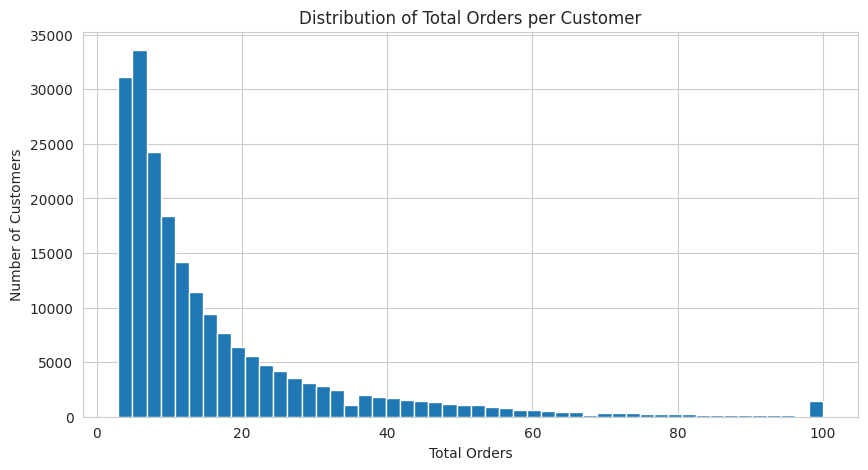

In [127]:
# PLOT 1: Distribution of Total Orders per Customer
# This tells us how many orders each customer placed in their lifetime.
# We expect a right-skewed distribution — most customers place very few orders
# before disengaging, while a small group becomes highly loyal.
# The spike at 100 is a data cap — Instacart limited order history to 100 orders.

customer_summary['total_orders'].hist(bins=50, figsize=(10,5))
plt.title('Distribution of Total Orders per Customer')
plt.xlabel('Total Orders')
plt.ylabel('Number of Customers')
plt.show()

**Observations**: Most customers placed fewer than 20 orders total, suggesting Instacart struggles to convert early users into long-term habitual shoppers.


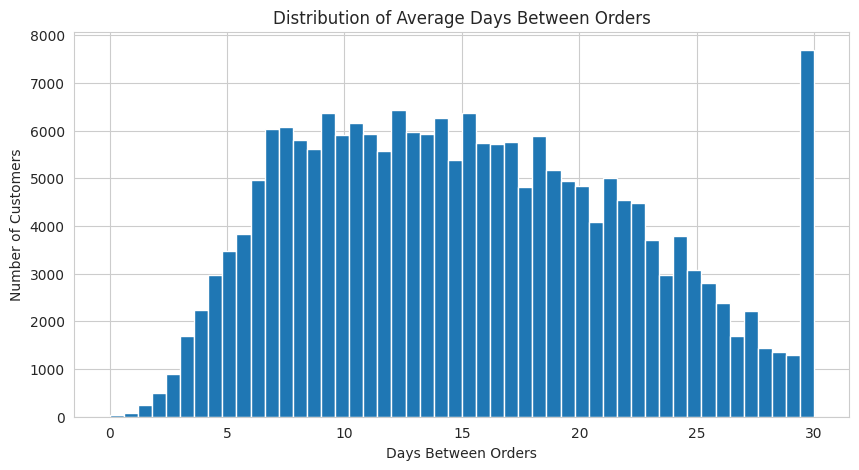

In [128]:
# PLOT 2: Distribution of Average Days Between Orders
# This tells us how frequently customers typically order.
# Active customers tend to order every 7-15 days.
# The spike at 30 is NOT real customer behavior — it's a data artifact.
# Instacart capped the days_since_prior_order field at 30,
# so all customers who waited longer than 30 days show up as 30.
# These are likely churned customers piling up at the cap.

customer_summary['avg_days_between'].hist(bins=50, figsize=(10,5))
plt.title('Distribution of Average Days Between Orders')
plt.xlabel('Days Between Orders')
plt.ylabel('Number of Customers')
plt.show()

**Observations**: Ordering cadence peaks between 7–15 days for active customers.
The spike at 30 days is a data cap artifact, these are likely churned customers.

In [129]:
# CREATE CHURN FLAG
# There is no churn column in the raw data — we have to derive it.
# We use a BEHAVIORAL definition instead of a fixed threshold.
#
# WHY NOT max_gap == 30?
# That flagged 71% of customers as churned — too aggressive.
# A customer who orders every 30 days would get incorrectly flagged.
#
# WHY max_gap > (avg_days_between * 2)?
# This personalizes the threshold to each customer's own pattern.
# A weekly shopper (7 days avg) is churning if they go 14+ days without ordering.
# A monthly shopper (20 days avg) is fine at 30 days — that's normal for them.
# If someone breaks their own pattern by 2x, that's a meaningful signal.
#
# This mirrors the exact definition used in our SQL CHURN_FLAGS table.

customer_summary['churned'] = (
    customer_summary['max_gap'] > (customer_summary['avg_days_between'] * 2)
).astype(int)

In [130]:
customer_summary['churned'].mean()

np.float64(0.3988041259110902)

In [131]:
# CREATE CUSTOMER SEGMENTS
# Groups customers by their typical ordering cadence.
# Uses np.select — Python's equivalent of SQL CASE WHEN.
# It checks each condition row by row and assigns the first matching label.
#
# These buckets map to real shopping behaviors:
#   High Frequency  (<=7 days)  — weekly shoppers, fresh produce, daily essentials
#   Medium Frequency (<=14 days) — bi-weekly shoppers, regular household stock-ups
#   Low Frequency   (<=21 days) — monthly shoppers, bulk or occasional
#   Infrequent      (22+ days)  — rare shoppers, nearly lapsed
#
# Mirrors the exact segmentation used in our SQL CHURN_FLAGS table.

conditions = [
    customer_summary['avg_days_between'] <= 7,
    customer_summary['avg_days_between'] <= 14,
    customer_summary['avg_days_between'] <= 21,

]
choices = ['High Frequency', 'Medium Frequency', 'Low Frequency']

customer_summary['customer_segment'] = np.select(conditions, choices, default='Infrequent')
counts = customer_summary['customer_segment'].value_counts()
counts['TOTAL'] = counts.sum()
print(counts)

customer_segment
Medium Frequency     70080
Low Frequency        63593
Infrequent           47007
High Frequency       25529
TOTAL               206209
Name: count, dtype: int64


In [132]:
customer_summary['customer_segment'].value_counts()

,count
customer_segment,
Medium Frequency,70080
Low Frequency,63593
Infrequent,47007
High Frequency,25529


## Section 2: Churn Segmentation

In [133]:
# CHURN RATE BY CUSTOMER SEGMENT
# Groups customers by frequency segment and calculates churn rate for each.
# Sorted highest to lowest so the chart reads dark to light left to right.

churn_by_segment = customer_summary.groupby('customer_segment')['churned'].mean().mul(100).round(2).reset_index()
churn_by_segment.columns = ['customer_segment', 'churn_rate']
churn_by_segment = churn_by_segment.sort_values('churn_rate', ascending=False)

# 4 pastel orange shades — one per segment, darkest = highest churn
colors = ['#E8733A', '#F0976A', '#F7BB9A', '#FDE0CC']

fig = px.bar(churn_by_segment,
             x='customer_segment',
             y='churn_rate',
             title='Churn Rate by Customer Segment',
             labels={'customer_segment': 'Customer Segment', 'churn_rate': 'Churn Rate (%)'},
             color='customer_segment',
             color_discrete_sequence=colors)
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

**Observations**: High and Medium Frequency customers churn at ~80%  counterintuitive but meaningful.
These customers have a strong ordering pattern, so when they break it, it's a clear signal.
Infrequent customers barely churn by this definition because their baseline gap is already wide.

In [134]:
# CREATE ORDER BUCKET
# We need to group customers by how many total orders they placed.
# Instead of using raw numbers (3, 7, 45), we create ranges (buckets)
# so we can easily compare groups of customers against each other.

# Define the conditions — checked top to bottom, first match wins
conditions = [
    customer_summary['total_orders'] <= 5,   # trial customers, just getting started
    customer_summary['total_orders'] <= 10,  # early habit formation — critical drop-off zone
    customer_summary['total_orders'] <= 20,  # developing loyal customers
    customer_summary['total_orders'] <= 50   # regular customers
]

# Labels assigned to each condition above, in the same order
choices = ['1-5', '6-10', '11-20', '21-50']

# np.select checks each row against conditions and assigns the matching label
# default='50+' catches anyone who didn't match any condition above
customer_summary['order_bucket'] = np.select(conditions, choices, default='50+')

In [135]:
# Count how many customers fall into each order bucket
counts = customer_summary['order_bucket'].value_counts()

# Add a TOTAL row to confirm all 206,209 customers are accounted for
counts['TOTAL'] = counts.sum()
print(counts)

order_bucket
6-10      58027
1-5       49404
11-20     49098
21-50     38980
50+       10700
TOTAL    206209
Name: count, dtype: int64


In [136]:
# Group all customers by their order bucket
# Then calculate what percentage of each group churned
churn_by_bucket = customer_summary.groupby('order_bucket')['churned'].mean().mul(100).round(2).reset_index()

# Rename columns so they're readable in the chart
churn_by_bucket.columns = ['order_bucket', 'churn_rate']

# Sort highest churn first so the chart reads left to right, dark to light
churn_by_bucket = churn_by_bucket.sort_values('churn_rate', ascending=False)

In [137]:
# CHURN RATE BY ORDER COUNT BUCKET
# This chart answers: which order count group churns the most?

# Explicit color map — instead of letting plotly assign colors automatically,
# we manually map each bucket to a specific shade of orange.
# Darkest orange = highest churn (50+), lightest = lowest churn (1-5)
# This makes the chart intuitive — darker means more at risk
color_map = {
    '50+': '#E8733A',    # darkest — highest churn
    '21-50': '#F0976A',  # dark orange
    '11-20': '#F7BB9A',  # medium orange
    '6-10': '#FDE0CC',   # light orange
    '1-5': '#FFF5EE'     # lightest — lowest churn
}

# Build the interactive bar chart
fig = px.bar(churn_by_bucket,
             x='order_bucket',     # x-axis: the five order count buckets
             y='churn_rate',       # y-axis: churn rate as a percentage
             title='Churn Rate by Order Count Bucket',
             labels={'order_bucket': 'Order Count Bucket', 'churn_rate': 'Churn Rate (%)'},
             color='order_bucket',         # color each bar by its bucket name
             color_discrete_map=color_map) # use our manual color map above


# Render the interactive chart — hover to see exact churn rate per bucket
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

**Observations:** Churn rises with order count! customers with 50+ orders churn at 97% under
the behavioral definition. More orders means more chances to break their pattern.
The 1-5 bucket churns least because new customers haven't established a pattern yet.

In [138]:
# Count how many customers reached each order number
order_sequence = orders_clean.groupby('order_number')['user_id'].nunique().reset_index()
order_sequence.columns = ['order_number', 'customer_count']

In [139]:
# Customer drop-off by order number
# Highlights the critical intervention window between orders 5-10

fig = px.line(order_sequence,
              x='order_number',
              y='customer_count',
              title='Customer Drop-off by Order Number',
              labels={'order_number': 'Order Number', 'customer_count': 'Active Customers'},
              color_discrete_sequence=['#E8733A'])

# Add shaded region to highlight the critical drop-off window
fig.add_vrect(x0=5, x1=10,
              fillcolor='#FFE5CC', opacity=0.4,
              layer='below', line_width=0,
              annotation_text='Critical Drop-off Window',
              annotation_position='top left')
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')


fig.show()

**Observations:** 48,634 customers dropped off between order 5 and order 10, the steepest decline
in the entire dataset. This is the critical intervention window. If Instacart can
retain customers through their first 10 orders, they are significantly more likely
to become long-term habitual shoppers.

## Section 3: Behavioral Signatures

This section examines how customer behavior changes over their order sequence.
The goal is to identify early warning signals that precede churn like what does
a customer look like before they disengage?

In [140]:
# Load the order products file — this has one row per item per order
# We need this to calculate basket size (how many items per order)
# and reorder rate (what % of items were bought before)
order_products = pd.read_csv(BASE_PATH + 'order_products__prior.csv')
order_products.head()

,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


In [141]:
# CALCULATE BASKET SIZE
# order_products has one row per item — e.g. order 2 with 9 items has 9 rows
# We collapse it to one row per order and count the items
basket_size = order_products.groupby('order_id')['product_id'].count().reset_index()
basket_size.columns = ['order_id', 'basket_size']

In [142]:
# Join basket size onto orders_clean so each order now has its item count
# We use left join to keep all orders even if basket size is missing
orders_with_basket = orders_clean.merge(basket_size, on='order_id', how='left')
orders_with_basket.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,basket_size
0,2539329,1,prior,1,2,8,NaN,5.0
1,2398795,1,prior,2,3,7,15.0,6.0
2,473747,1,prior,3,3,12,21.0,5.0
3,2254736,1,prior,4,4,7,29.0,5.0
4,431534,1,prior,5,4,15,28.0,8.0


In [143]:
# Average basket size at each order number across all customers
# This tells us: do customers buy more or fewer items as they order more?
basket_by_order = orders_with_basket.groupby('order_number')['basket_size'].mean().reset_index()
basket_by_order.columns = ['order_number', 'avg_basket_size']

In [144]:
# CHART: Average Basket Size by Order Number
# Finding: basket size stays flat around 10 items — it does NOT drop
# in the critical window. Basket size is not an early churn signal.
fig = px.line(basket_by_order,
              x='order_number',
              y='avg_basket_size',
              title='Average Basket Size by Order Number',
              labels={'order_number': 'Order Number', 'avg_basket_size': 'Avg Basket Size'},
              color_discrete_sequence=['#E8733A'])
fig.add_vrect(x0=5, x1=10, fillcolor='#FFE5CC', opacity=0.4,
              layer='below', line_width=0,
              annotation_text='Critical Drop-off Window',
              annotation_position='top left')
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

In [145]:
# Calculate average reorder rate per order and join to our orders dataframe
# reordered = 1 means the customer bought this item before, 0 means it's new
# Taking the mean gives us the % of items in each order that were reorders
reorder_data = order_products[['order_id', 'reordered']]
orders_with_reorder = orders_with_basket.merge(
    reorder_data.groupby('order_id')['reordered'].mean().reset_index(),
    on='order_id', how='left')

In [146]:
orders_with_reorder.head()

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order,basket_size,reordered
0,2539329,1,prior,1,2,8,NaN,5.0,0.000
1,2398795,1,prior,2,3,7,15.0,6.0,0.500
2,473747,1,prior,3,3,12,21.0,5.0,0.600
3,2254736,1,prior,4,4,7,29.0,5.0,1.000
4,431534,1,prior,5,4,15,28.0,8.0,0.625


In [147]:
# Average reorder rate at each order number across all customers
# This tells us: do customers buy more familiar items as they order more?
reorder_by_order = orders_with_reorder.groupby('order_number')['reordered'].mean().reset_index()
reorder_by_order.columns = ['order_number', 'avg_reorder_rate']

In [148]:
# CHART: Reorder Rate by Order Number
# Finding: reorder rate climbs steadily from 0% to 85%+
# Customers who survive the drop-off window become creatures of habit
# This is the strongest loyalty signal in the dataset
fig = px.line(reorder_by_order,
              x='order_number',
              y='avg_reorder_rate',
              title='Reorder Rate by Order Number',
              labels={'order_number': 'Order Number', 'avg_reorder_rate': 'Reorder Rate'},
              color_discrete_sequence=['#E8733A'])
fig.add_vrect(x0=5, x1=10, fillcolor='#FFE5CC', opacity=0.4,
              layer='below', line_width=0,
              annotation_text='Critical Drop-off Window',
              annotation_position='top left')
fig.update_layout(plot_bgcolor='white', paper_bgcolor='white')
fig.show()

## Section 4: Key Findings

## Key Findings

1. **39.88% behavioral churn rate** — 4 in 10 Instacart customers broke their
   ordering pattern, using a personalized 2x average gap threshold.

2. **Critical drop-off window: orders 5–10** — 48,634 customers disengaged
   in this window. This is the highest-leverage intervention point.

3. **High and Medium Frequency customers churn most (~80%)** — customers with
   strong ordering habits show the clearest churn signal when they break pattern.

4. **Basket size is not an early warning signal** — basket size stays flat
   through the drop-off window, only declining after order 50+.

5. **Reorder rate is the strongest loyalty indicator** — rising from 0% at
   order 1 to 65% by order 10. Customers who survive the drop-off window
   develop strong repeat purchasing habits.

6. **Recommendation** — retention efforts should target customers between
   their 5th and 10th order, before habits are formed or lost.